<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/ML_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###1. Write a Python program to compute the mean of a given list of numbers.
###2. Calculate the median of an even-sized dataset using Python.
###3. Find the mode of a dataset that contains repeated value.
###4. Compute the standard deviation of a dataset using NumP

In [ ]:
import numpy as np
from scipy import stats

In [ ]:
lst = [23,53,23,5,43,12,65,73,57,20]
print(np.mean(lst))
print(np.median(lst))
print(stats.mode(lst))
print(np.std(lst))

37.4
33.0
ModeResult(mode=np.int64(23), count=np.int64(2))
22.584065178793654


### 5. Compare mean and median for a skewed dataset
###6. Identify whether the dataset is positively or negatively skewed using Python.
###7. Plot a histogram to visualize the data distribution of a numeric feature.
###8. Calculate minimum, maximum, and range of a datase

Skewed Dataset (first 10 values): [1.29 1.56 0.11 2.77 0.88 0.7  3.27 0.15 0.18 1.76]
Mean of the skewed dataset: 1.9847
Median of the skewed dataset: 1.3665


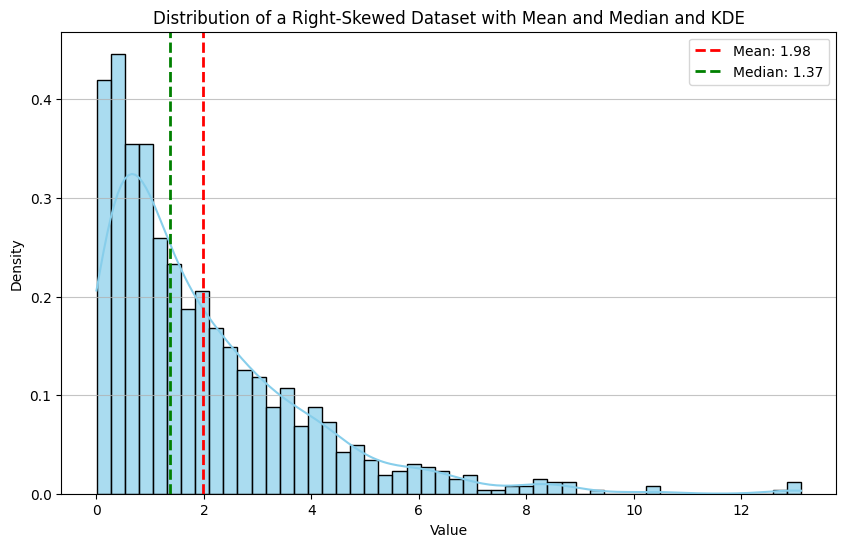

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn

# Generate a right-skewed dataset (e.g., using exponential distribution)
skewed_data = np.random.exponential(scale=2.0, size=1000)

# Calculate the mean and median
mean_skewed = np.mean(skewed_data)
median_skewed = np.median(skewed_data)

print(f"Skewed Dataset (first 10 values): {skewed_data[:10].round(2)}")
print(f"Mean of the skewed dataset: {mean_skewed:.4f}")
print(f"Median of the skewed dataset: {median_skewed:.4f}")

# Visualize the distribution to show skewness and the position of mean/median
plt.figure(figsize=(10, 6))
sns.histplot(skewed_data, bins=50, stat='density', alpha=0.7, color='skyblue', edgecolor='black', kde=True) # Use sns.histplot with kde=True
plt.axvline(mean_skewed, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_skewed:.2f}')
plt.axvline(median_skewed, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_skewed:.2f}')
plt.title('Distribution of a Right-Skewed Dataset with Mean and Median and KDE')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
from scipy.stats import skew

skewness_coefficient = skew(skewed_data)
print(f"\nSkewness coefficient of the dataset: {skewness_coefficient:.4f}")

if skewness_coefficient > 0:
    print("The dataset is positively (right) skewed.")
elif skewness_coefficient < 0:
    print("The dataset is negatively (left) skewed.")
else:
    print("The dataset is approximately symmetric (skewness close to zero).")

min_value = np.min(skewed_data)
max_value = np.max(skewed_data)
range_value = max_value - min_value

print(f"\nMinimum value of the dataset: {min_value:.4f}")
print(f"Maximum value of the dataset: {max_value:.4f}")
print(f"Range of the dataset (Max - Min): {range_value:.4f}")



Skewness coefficient of the dataset: 1.9039
The dataset is positively (right) skewed.

Minimum value of the dataset: 0.0006
Maximum value of the dataset: 13.1113
Range of the dataset (Max - Min): 13.1107


####LEVEL 2: INTERMEDIATE (Application & Interpretation)

###1. Detect outliers using IQR method and list the outlier values.
###2. Remove outliers from a dataset and compute the new mean and standard deviation


In [ ]:
Q1 = np.percentile(skewed_data, 25)
Q3 = np.percentile(skewed_data, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = skewed_data[(skewed_data < lower_bound) | (skewed_data > upper_bound)]

print(f"First Quartile (Q1): {Q1:.4f}")
print(f"Third Quartile (Q3): {Q3:.4f}")
print(f"Interquartile Range (IQR): {IQR:.4f}")
print(f"Lower Bound for Outliers: {lower_bound:.4f}")
print(f"Upper Bound for Outliers: {upper_bound:.4f}")
print(f"Identified Outliers: {outliers.round(4)}")

First Quartile (Q1): 0.5893
Third Quartile (Q3): 2.7856
Interquartile Range (IQR): 2.1963
Lower Bound for Outliers: -2.7052
Upper Bound for Outliers: 6.0801
Identified Outliers: [ 8.278   7.1941  6.568  10.3541  6.1337  6.8232  6.6598  8.1263  6.4071
 10.4214 13.0655  9.4381  7.3827 13.1113 12.9544  6.6778  7.7127  8.5167
  6.9121  6.3314  7.0108  8.1694  6.1307  8.3045  8.8343  6.6132  8.5876
  8.1852  8.7705  6.446   8.4999  6.4509  6.9186  7.8429  8.0791  7.0406
  8.6823  6.2961 12.7499  6.3866]


In [ ]:
cleaned_data = skewed_data[(skewed_data >= lower_bound) & (skewed_data <= upper_bound)]

mean_cleaned = np.mean(cleaned_data)
std_cleaned = np.std(cleaned_data)

print(f"Original dataset size: {len(skewed_data)}")
print(f"Number of outliers removed: {len(outliers)}")
print(f"Cleaned dataset size: {len(cleaned_data)}")
print(f"Mean of the cleaned dataset: {mean_cleaned:.4f}")
print(f"Standard deviation of the cleaned dataset: {std_cleaned:.4f}")

Original dataset size: 1000
Number of outliers removed: 40
Cleaned dataset size: 960
Mean of the cleaned dataset: 1.7288
Standard deviation of the cleaned dataset: 1.4487


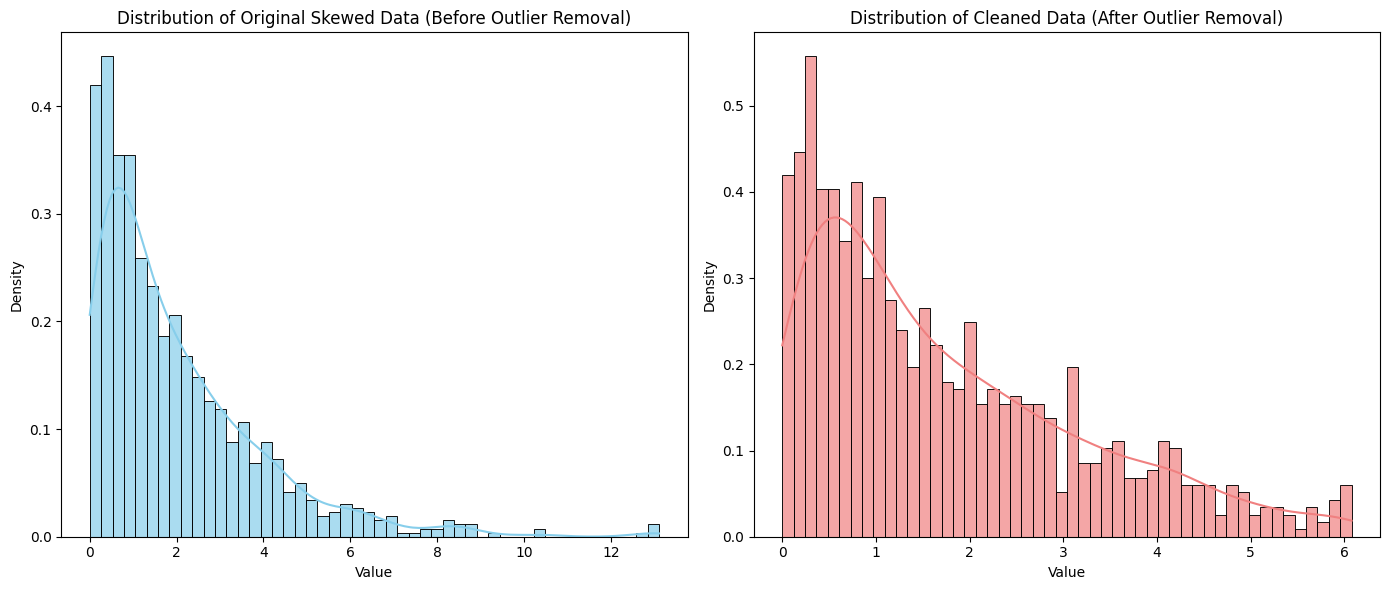

In [ ]:
plt.figure(figsize=(14, 6))

# Plot for original skewed_data
plt.subplot(1, 2, 1)
sns.histplot(skewed_data, bins=50, stat='density', alpha=0.7, color='skyblue', edgecolor='black', kde=True)
plt.title('Distribution of Original Skewed Data (Before Outlier Removal)')
plt.xlabel('Value')
plt.ylabel('Density')

# Plot for cleaned_data
plt.subplot(1, 2, 2)
sns.histplot(cleaned_data, bins=50, stat='density', alpha=0.7, color='lightcoral', edgecolor='black', kde=True)
plt.title('Distribution of Cleaned Data (After Outlier Removal)')
plt.xlabel('Value')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

###3. Perform Min–Max normalization on a given dataset using Python

In [ ]:
min_cleaned_data = np.min(cleaned_data)
max_cleaned_data = np.max(cleaned_data)

min_max_normalized_data = (cleaned_data - min_cleaned_data) / (max_cleaned_data - min_cleaned_data)

print(f"Minimum value of cleaned_data: {min_cleaned_data:.4f}")
print(f"Maximum value of cleaned_data: {max_cleaned_data:.4f}")
print(f"First 10 values of cleaned_data: {cleaned_data[:10].round(4)}")
print(f"First 10 values of Min-Max normalized data: {min_max_normalized_data[:10].round(4)}")

Minimum value of cleaned_data: 0.0006
Maximum value of cleaned_data: 6.0769
First 10 values of cleaned_data: [1.2901 1.561  0.1067 2.7716 0.8808 0.7003 3.2704 0.1473 0.1818 1.7558]
First 10 values of Min-Max normalized data: [0.2122 0.2568 0.0175 0.456  0.1449 0.1151 0.5381 0.0241 0.0298 0.2889]


###4. Apply Z-score standardization and verify that the transformed data has mean 0 and standard deviation 1

In [ ]:
mean_cleaned_data = np.mean(cleaned_data)
std_cleaned_data = np.std(cleaned_data)

z_score_standardized_data = (cleaned_data - mean_cleaned_data) / std_cleaned_data

print(f"Mean of cleaned_data: {mean_cleaned_data:.4f}")
print(f"Standard deviation of cleaned_data: {std_cleaned_data:.4f}")
print(f"First 10 values of Z-score standardized data: {z_score_standardized_data[:10].round(4)}")

Mean of cleaned_data: 1.7288
Standard deviation of cleaned_data: 1.4487
First 10 values of Z-score standardized data: [-0.3028 -0.1159 -1.1197  0.7198 -0.5854 -0.71    1.0641 -1.0917 -1.0679
  0.0186]


###5. Compare normalized and standardized datasets using summary statistics



In [ ]:
import pandas as pd

# Create a DataFrame for easy comparison of summary statistics
df_comparison = pd.DataFrame({
    'Cleaned Data': cleaned_data,
    'Min-Max Normalized Data': min_max_normalized_data,
    'Z-score Standardized Data': z_score_standardized_data
})

print("Summary Statistics of Cleaned Data:")
print(df_comparison['Cleaned Data'].describe())
print("\nSummary Statistics of Min-Max Normalized Data:")
print(df_comparison['Min-Max Normalized Data'].describe())
print("\nSummary Statistics of Z-score Standardized Data:")
print(df_comparison['Z-score Standardized Data'].describe())


Summary Statistics of Cleaned Data:
count    960.000000
mean       1.728834
std        1.449469
min        0.000632
25%        0.562425
50%        1.308113
75%        2.586436
max        6.076860
Name: Cleaned Data, dtype: float64

Summary Statistics of Min-Max Normalized Data:
count    960.000000
mean       0.284420
std        0.238548
min        0.000000
25%        0.092458
50%        0.215180
75%        0.425561
max        1.000000
Name: Min-Max Normalized Data, dtype: float64

Summary Statistics of Z-score Standardized Data:
count    9.600000e+02
mean    -5.181041e-17
std      1.000521e+00
min     -1.192922e+00
25%     -8.051342e-01
50%     -2.904103e-01
75%      5.919742e-01
max      3.001300e+00
Name: Z-score Standardized Data, dtype: float64


###6. Visualize data before and after normalization using boxplots


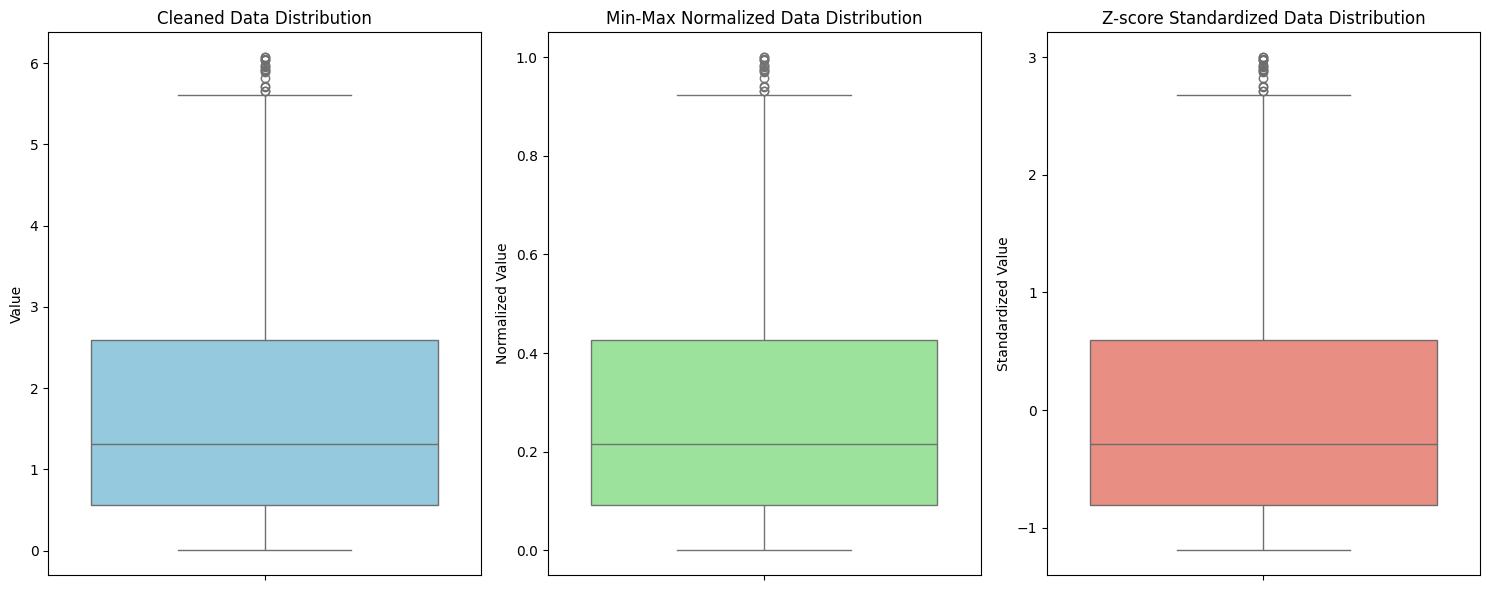

In [ ]:
plt.figure(figsize=(15, 6))

# Boxplot for Cleaned Data
plt.subplot(1, 3, 1)
sns.boxplot(y=cleaned_data, color='skyblue')
plt.title('Cleaned Data Distribution')
plt.ylabel('Value')

# Boxplot for Min-Max Normalized Data
plt.subplot(1, 3, 2)
sns.boxplot(y=min_max_normalized_data, color='lightgreen')
plt.title('Min-Max Normalized Data Distribution')
plt.ylabel('Normalized Value')

# Boxplot for Z-score Standardized Data
plt.subplot(1, 3, 3)
sns.boxplot(y=z_score_standardized_data, color='salmon')
plt.title('Z-score Standardized Data Distribution')
plt.ylabel('Standardized Value')

plt.tight_layout()
plt.show()

###7. Calculate the covariance between two variables using Python.

In [ ]:
import numpy as np

x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

print(f"Sample array x: {x}")
print(f"Sample array y: {y}")

covariance_matrix = np.cov(x, y)
print(f"\nCovariance Matrix:\n{covariance_matrix}")

covariance_xy = covariance_matrix[0, 1]
print(f"\nCovariance between x and y: {covariance_xy:.4f}")

Sample array x: [1 2 3 4 5]
Sample array y: [2 4 5 4 5]

Covariance Matrix:
[[2.5 1.5]
 [1.5 1.5]]

Covariance between x and y: 1.5000


###8. Compute the Pearson correlation coefficient and interpret the result

In [ ]:
import numpy as np

correlation_matrix = np.corrcoef(x, y)
print(f"\nPearson Correlation Matrix:\n{correlation_matrix}")

pearson_correlation_xy = correlation_matrix[0, 1]
print(f"\nPearson Correlation coefficient between x and y: {pearson_correlation_xy:.4f}")


Pearson Correlation Matrix:
[[1.         0.77459667]
 [0.77459667 1.        ]]

Pearson Correlation coefficient between x and y: 0.7746


###9. Show the difference between correlation and covariance using a numerical example

In [ ]:
import numpy as np

# Generate the first pair of datasets with a perfect positive linear relationship (y1 = 2 * x1)
x1 = np.array([1, 2, 3, 4, 5])
y1 = 2 * x1

# Generate the second pair of datasets with a perfect positive linear relationship (y2 = 5 * x2)
x2 = np.array([1, 2, 3, 4, 5])
y2 = 5 * x2

print(f"Dataset 1: x1={x1}, y1={y1}")
print(f"Dataset 2: x2={x2}, y2={y2}")

Dataset 1: x1=[1 2 3 4 5], y1=[ 2  4  6  8 10]
Dataset 2: x2=[1 2 3 4 5], y2=[ 5 10 15 20 25]


In [ ]:
import numpy as np

cov_x1y1 = np.cov(x1, y1)[0, 1]
corr_x1y1 = np.corrcoef(x1, y1)[0, 1]

cov_x2y2 = np.cov(x2, y2)[0, 1]
corr_x2y2 = np.corrcoef(x2, y2)[0, 1]

print(f"\n--- Dataset 1 (x1, y1) ---")
print(f"Covariance (x1, y1): {cov_x1y1:.4f}")
print(f"Correlation (x1, y1): {corr_x1y1:.4f}")

print(f"\n--- Dataset 2 (x2, y2) ---")
print(f"Covariance (x2, y2): {cov_x2y2:.4f}")
print(f"Correlation (x2, y2): {corr_x2y2:.4f}")


--- Dataset 1 (x1, y1) ---
Covariance (x1, y1): 5.0000
Correlation (x1, y1): 1.0000

--- Dataset 2 (x2, y2) ---
Covariance (x2, y2): 12.5000
Correlation (x2, y2): 1.0000


covariance shows that both variable are positivley correleted but it does not shows that how much they are correleted for that correlation is used in this you can clerely see that they are perfectly postively correleted where both of them correlation is 1

###10. Generate a scatter plot to visualize correlation between two features

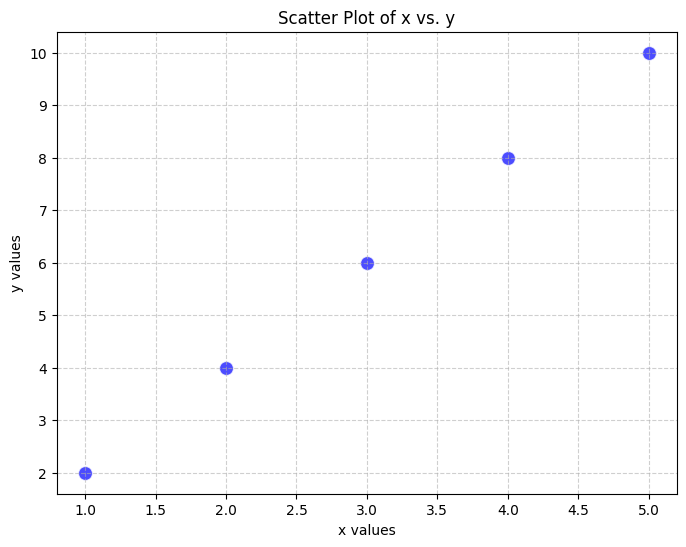

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of x and y
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x1, y=y1, color='blue', s=100, alpha=0.7)
plt.title('Scatter Plot of x vs. y')
plt.xlabel('x values')
plt.ylabel('y values')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

####LEVEL 3: ADVANCED (Analysis & Modeling)

###1. Write a Python function to compute mean, median, mode, and standard deviation without using built-in functions

In [ ]:
def calculate_mean(data):
    if not data:
        return None
    return sum(data) / len(data)

def calculate_median(data):
    if not data:
        return None
    sorted_data = sorted(data)
    n = len(sorted_data)
    if n % 2 == 1:
        return sorted_data[n // 2]
    else:
        mid1 = sorted_data[n // 2 - 1]
        mid2 = sorted_data[n // 2]
        return (mid1 + mid2) / 2

def calculate_mode(data):
    if not data:
        return []
    frequency = {}
    for item in data:
        frequency[item] = frequency.get(item, 0) + 1

    if not frequency:
        return []

    max_frequency = 0
    for count in frequency.values():
        if count > max_frequency:
            max_frequency = count

    modes = []
    for item, count in frequency.items():
        if count == max_frequency:
            modes.append(item)

    return modes

def calculate_std_dev(data):
    if len(data) < 2:
        return 0.0 # Standard deviation is typically 0 for a single element or undefined for empty list

    mean_val = calculate_mean(data)
    if mean_val is None:
        return 0.0 # Handle empty list case

    squared_diffs = [(x - mean_val) ** 2 for x in data]
    variance = sum(squared_diffs) / (len(data) - 1) # Using sample standard deviation (n-1)
    return variance ** 0.5

print("Custom statistics functions (calculate_mean, calculate_median, calculate_mode, calculate_std_dev) have been defined.")

Custom statistics functions (calculate_mean, calculate_median, calculate_mode, calculate_std_dev) have been defined.


###2. Apply outlier removal and analyze its impact on correlation values

In [ ]:
np.random.seed(42)

# Generate a dataset with a positive correlation
x_corr = np.random.rand(100) * 10
y_corr = 2 * x_corr + np.random.randn(100) * 2

# Introduce some outliers
outlier_indices = np.random.choice(100, 5, replace=False)
y_corr[outlier_indices] = y_corr[outlier_indices] * 5  # Make some y values much larger

print(f"Original x_corr (first 10): {x_corr[:10].round(2)}")
print(f"Original y_corr (first 10): {y_corr[:10].round(2)}")

Original x_corr (first 10): [3.75 9.51 7.32 5.99 1.56 1.56 0.58 8.66 6.01 7.08]
Original y_corr (first 10): [ 7.66 18.42 74.12  8.    2.68  3.83  4.12 16.29 10.41 13.16]


In [ ]:
original_correlation = np.corrcoef(x_corr, y_corr)[0, 1]
print(f"Pearson correlation coefficient for the original dataset: {original_correlation:.4f}")

Pearson correlation coefficient for the original dataset: 0.5437


In [ ]:
Q1_y_corr = np.percentile(y_corr, 25)
Q3_y_corr = np.percentile(y_corr, 75)
IQR_y_corr = Q3_y_corr - Q1_y_corr

lower_bound_y_corr = Q1_y_corr - 1.5 * IQR_y_corr
upper_bound_y_corr = Q3_y_corr + 1.5 * IQR_y_corr

print(f"First Quartile (Q1) for y_corr: {Q1_y_corr:.4f}")
print(f"Third Quartile (Q3) for y_corr: {Q3_y_corr:.4f}")
print(f"Interquartile Range (IQR) for y_corr: {IQR_y_corr:.4f}")
print(f"Lower Bound for y_corr Outliers: {lower_bound_y_corr:.4f}")
print(f"Upper Bound for y_corr Outliers: {upper_bound_y_corr:.4f}")

First Quartile (Q1) for y_corr: 4.5726
Third Quartile (Q3) for y_corr: 14.7593
Interquartile Range (IQR) for y_corr: 10.1867
Lower Bound for y_corr Outliers: -10.7074
Upper Bound for y_corr Outliers: 30.0393


In [ ]:
mask = (y_corr >= lower_bound_y_corr) & (y_corr <= upper_bound_y_corr)
x_corr_cleaned = x_corr[mask]
y_corr_cleaned = y_corr[mask]

print(f"Original dataset size: {len(x_corr)}")
print(f"Number of outliers detected: {len(x_corr) - len(x_corr_cleaned)}")
print(f"Cleaned dataset size: {len(x_corr_cleaned)}")
print(f"Cleaned x_corr (first 10): {x_corr_cleaned[:10].round(2)}")
print(f"Cleaned y_corr (first 10): {y_corr_cleaned[:10].round(2)}")

Original dataset size: 100
Number of outliers detected: 3
Cleaned dataset size: 97
Cleaned x_corr (first 10): [3.75 9.51 5.99 1.56 1.56 0.58 8.66 6.01 7.08 0.21]
Cleaned y_corr (first 10): [ 7.66 18.42  8.    2.68  3.83  4.12 16.29 10.41 13.16  2.24]


In [ ]:
cleaned_correlation = np.corrcoef(x_corr_cleaned, y_corr_cleaned)[0, 1]
print(f"Pearson correlation coefficient for the cleaned dataset: {cleaned_correlation:.4f}")

Pearson correlation coefficient for the cleaned dataset: 0.9292


### 3.Compare Mean vs. Median Post-Outlier Removal


In [ ]:
original_mean_y = calculate_mean(list(y_corr))
original_median_y = calculate_median(list(y_corr))

cleaned_mean_y = calculate_mean(list(y_corr_cleaned))
cleaned_median_y = calculate_median(list(y_corr_cleaned))

print(f"Mean of original y_corr: {original_mean_y:.4f}")
print(f"Median of original y_corr: {original_median_y:.4f}")
print(f"\nMean of cleaned y_corr: {cleaned_mean_y:.4f}")
print(f"Median of cleaned y_corr: {cleaned_median_y:.4f}")

Mean of original y_corr: 11.5426
Median of original y_corr: 8.7684

Mean of cleaned y_corr: 9.3283
Median of cleaned y_corr: 8.2443


###5. Implement simple linear regression using scikit-learn
###6. Plot the regression line along with the data points.
###7. Interpret the slope and intercept of the regression model.
###8. Evaluate the regression model using R² score and RMSE.
###9. Analyze how outliers affect the regression line before and after removal.
###10. Perform regression after normalization and compare results with unscaled data

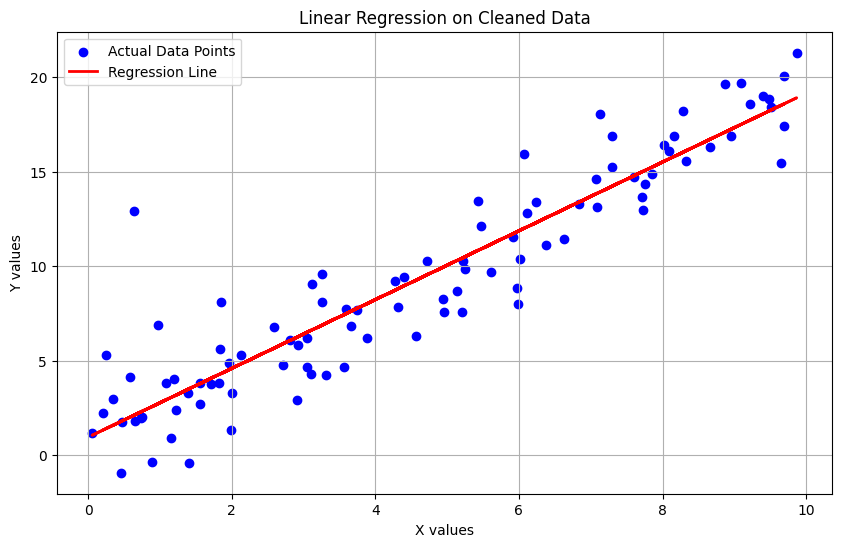

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 2. Reshape x_corr_cleaned to a 2D array
X_cleaned_reshaped = x_corr_cleaned.reshape(-1, 1)

# 3. Instantiate a LinearRegression model
model = LinearRegression()

# 4. Fit the linear regression model to the cleaned data
model.fit(X_cleaned_reshaped, y_corr_cleaned)

# 5. Generate predictions for x_corr_cleaned
y_pred = model.predict(X_cleaned_reshaped)

# 6. Create a scatter plot of x_corr_cleaned and y_corr_cleaned
plt.figure(figsize=(10, 6))
plt.scatter(x_corr_cleaned, y_corr_cleaned, color='blue', label='Actual Data Points')

# 7. Plot the regression line on the same scatter plot
plt.plot(x_corr_cleaned, y_pred, color='red', linewidth=2, label='Regression Line')

# 8. Add title, x-axis label, and y-axis label to the plot
plt.title('Linear Regression on Cleaned Data')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.legend()
plt.grid(True)

# 9. Display the plot
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# 1. Access and print the intercept of the model
print(f"Model Intercept: {model.intercept_:.4f}")

# 2. Access and print the slope (coefficient) of the model
print(f"Model Slope (Coefficient): {model.coef_[0]:.4f}")

# 4. Calculate the R-squared score
r2 = r2_score(y_corr_cleaned, y_pred)

# 5. Calculate the Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_corr_cleaned, y_pred)
rmse = np.sqrt(mse)

# 6. Print the calculated R-squared score and RMSE
print(f"R-squared Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Model Intercept: 0.9475
Model Slope (Coefficient): 1.8206
R-squared Score: 0.8634
Root Mean Squared Error (RMSE): 2.1356


In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Reshape the original independent variable x_corr to a 2D array
X_original_reshaped = x_corr.reshape(-1, 1)

# 2. Instantiate a new LinearRegression model
original_model = LinearRegression()

# 3. Fit this new linear regression model to the original data
original_model.fit(X_original_reshaped, y_corr)

# 4. Generate predictions for the original data using this model
y_pred_original = original_model.predict(X_original_reshaped)

print("Linear regression model fitted to original data, predictions generated.")

Linear regression model fitted to original data, predictions generated.


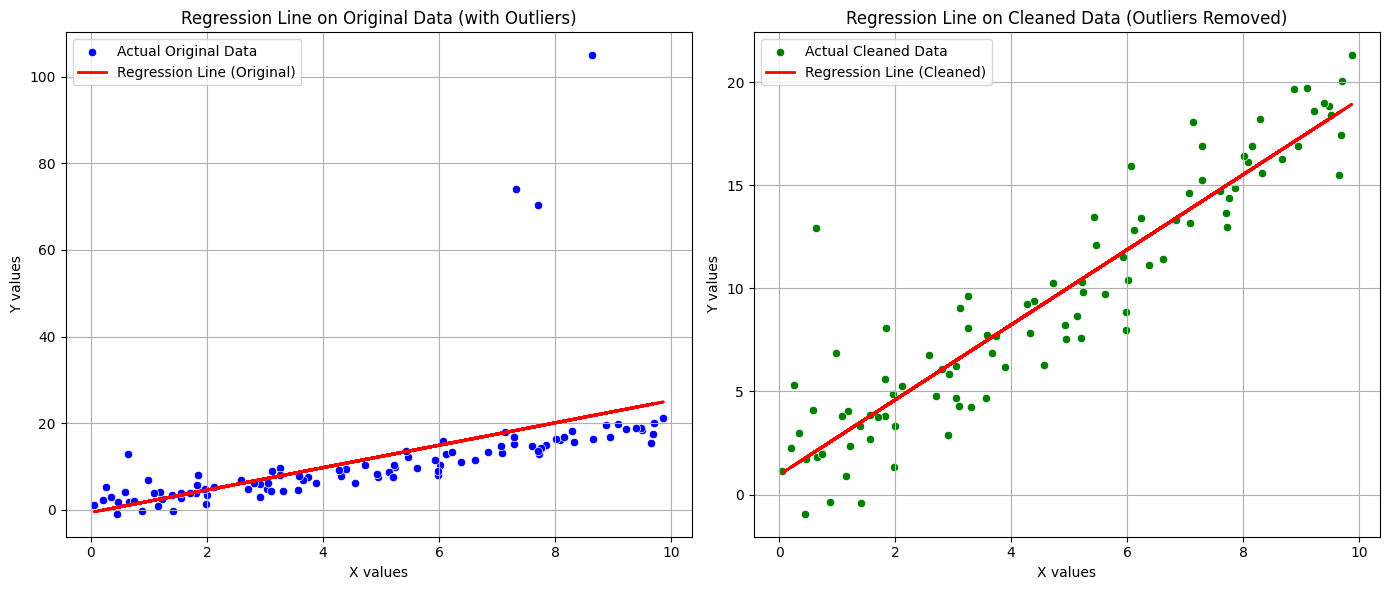

In [ ]:
plt.figure(figsize=(14, 6))

# Subplot 1: Original Data with Regression Line
plt.subplot(1, 2, 1)
sns.scatterplot(x=x_corr, y=y_corr, color='blue', label='Actual Original Data')
plt.plot(x_corr, y_pred_original, color='red', linewidth=2, label='Regression Line (Original)')
plt.title('Regression Line on Original Data (with Outliers)')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.legend()
plt.grid(True)

# Subplot 2: Cleaned Data with Regression Line
plt.subplot(1, 2, 2)
sns.scatterplot(x=x_corr_cleaned, y=y_corr_cleaned, color='green', label='Actual Cleaned Data')
plt.plot(x_corr_cleaned, y_pred, color='red', linewidth=2, label='Regression Line (Cleaned)')
plt.title('Regression Line on Cleaned Data (Outliers Removed)')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
original_model_intercept = original_model.intercept_
original_model_slope = original_model.coef_[0]

print(f"Original Model Intercept: {original_model_intercept:.4f}")
print(f"Original Model Slope (Coefficient): {original_model_slope:.4f}")

Original Model Intercept: -0.6146
Original Model Slope (Coefficient): 2.5856
